# Ensemble Model

This notebook combines predictions from all individual models (LSTM, Random Forest, XGBoost, AdaBoost) using ensemble strategies.

## Ensemble Strategies:
1. Simple Averaging
2. Weighted Averaging (based on model performance)
3. Voting Classifier (for classification)
4. Stacking (using meta-learners)

## Available Models:
- Random Forest (RF): Regression and Classification
- XGBoost (XGB): Regression and Classification
- AdaBoost (ADA): Regression and Classification
- LSTM: Will be included if available


In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
from sklearn.ensemble import VotingRegressor, VotingClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import cross_val_score
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")


✓ Libraries imported successfully!


## Step 1: Load Predictions from Available Models

Load predictions from all available models. Models that don't exist will be skipped.


In [ ]:
# Define paths and check which models are available
# Handle different working directories (notebooks/ vs project root)
import os

# Get current working directory
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

# Determine base path - if we're in notebooks/, go up one level
if os.path.basename(cwd) == 'notebooks':
    base_path = '..'
else:
    base_path = '.'

# Define paths relative to base
team_paths = {
    'lstm': os.path.join(base_path, 'models', 'lstm'),
    'random_forest': os.path.join(base_path, 'models', 'random_forest'),
    'xgboost_adaboost': os.path.join(base_path, 'models', 'xgboost_adaboost')
}

available_models = {}

# Check for Random Forest
rf_val_path = os.path.join(base_path, 'models', 'random_forest', 'predictions_val.csv')
rf_test_path = os.path.join(base_path, 'models', 'random_forest', 'predictions_test.csv')
print(f"Checking Random Forest: {rf_val_path} (exists: {os.path.exists(rf_val_path)})")
if os.path.exists(rf_val_path) and os.path.exists(rf_test_path):
    available_models['random_forest'] = {
        'val_path': rf_val_path,
        'test_path': rf_test_path,
        'name': 'Random Forest'
    }
    print("✓ Random Forest predictions found")

# Check for XGBoost/AdaBoost
xgb_val_path = os.path.join(base_path, 'models', 'xgboost_adaboost', 'predictions_val.csv')
xgb_test_path = os.path.join(base_path, 'models', 'xgboost_adaboost', 'predictions_test.csv')
print(f"Checking XGBoost/AdaBoost: {xgb_val_path} (exists: {os.path.exists(xgb_val_path)})")
if os.path.exists(xgb_val_path) and os.path.exists(xgb_test_path):
    available_models['xgboost_adaboost'] = {
        'val_path': xgb_val_path,
        'test_path': xgb_test_path,
        'name': 'XGBoost/AdaBoost'
    }
    print("✓ XGBoost/AdaBoost predictions found")

# Check for LSTM
lstm_val_path = os.path.join(base_path, 'models', 'lstm', 'predictions_val.csv')
lstm_test_path = os.path.join(base_path, 'models', 'lstm', 'predictions_test.csv')
print(f"Checking LSTM: {lstm_val_path} (exists: {os.path.exists(lstm_val_path)})")
if os.path.exists(lstm_val_path) and os.path.exists(lstm_test_path):
    available_models['lstm'] = {
        'val_path': lstm_val_path,
        'test_path': lstm_test_path,
        'name': 'LSTM'
    }
    print("✓ LSTM predictions found")
else:
    print("⚠ LSTM predictions not found - will skip LSTM in ensemble")

print(f"\n✓ Total available models: {len(available_models)}")
print(f"Available models: {', '.join([m['name'] for m in available_models.values()])}")


Current working directory: c:\Users\hrudi\OneDrive\Documents\TAMU\SHADE\ML-Repo\notebooks
Checking Random Forest: ..\teams\random_forest\predictions_val.csv (exists: True)
✓ Random Forest predictions found
Checking XGBoost/AdaBoost: ..\teams\xgboost_adaboost\predictions_val.csv (exists: True)
✓ XGBoost/AdaBoost predictions found
Checking LSTM: ..\teams\lstm\predictions_val.csv (exists: False)
⚠ LSTM predictions not found - will skip LSTM in ensemble

✓ Total available models: 2
Available models: Random Forest, XGBoost/AdaBoost


In [23]:
# Load predictions from available models
predictions_val = {}
predictions_test = {}

# Load Random Forest predictions
if 'random_forest' in available_models:
    rf_val = pd.read_csv(available_models['random_forest']['val_path'])
    rf_test = pd.read_csv(available_models['random_forest']['test_path'])
    
    # Standardize column names
    rf_val = rf_val.rename(columns={
        'predicted_heat_index': 'rf_predicted_heat_index',
        'predicted_heat_risk': 'rf_predicted_heat_risk',
        'predicted_heat_risk_proba': 'rf_predicted_heat_risk_proba'
    })
    rf_test = rf_test.rename(columns={
        'predicted_heat_index': 'rf_predicted_heat_index',
        'predicted_heat_risk': 'rf_predicted_heat_risk',
        'predicted_heat_risk_proba': 'rf_predicted_heat_risk_proba'
    })
    
    predictions_val['random_forest'] = rf_val
    predictions_test['random_forest'] = rf_test
    print(f"✓ Loaded Random Forest: {len(rf_val)} validation, {len(rf_test)} test samples")

# Load XGBoost/AdaBoost predictions
if 'xgboost_adaboost' in available_models:
    xgb_val = pd.read_csv(available_models['xgboost_adaboost']['val_path'])
    xgb_test = pd.read_csv(available_models['xgboost_adaboost']['test_path'])
    
    predictions_val['xgboost_adaboost'] = xgb_val
    predictions_test['xgboost_adaboost'] = xgb_test
    print(f"✓ Loaded XGBoost/AdaBoost: {len(xgb_val)} validation, {len(xgb_test)} test samples")

# Load LSTM predictions
if 'lstm' in available_models:
    lstm_val = pd.read_csv(available_models['lstm']['val_path'])
    lstm_test = pd.read_csv(available_models['lstm']['test_path'])
    
    # Standardize column names
    lstm_val = lstm_val.rename(columns={
        'predicted_heat_index': 'lstm_predicted_heat_index',
        'predicted_heat_risk': 'lstm_predicted_heat_risk',
        'predicted_heat_risk_proba': 'lstm_predicted_heat_risk_proba'
    })
    lstm_test = lstm_test.rename(columns={
        'predicted_heat_index': 'lstm_predicted_heat_index',
        'predicted_heat_risk': 'lstm_predicted_heat_risk',
        'predicted_heat_risk_proba': 'lstm_predicted_heat_risk_proba'
    })
    
    predictions_val['lstm'] = lstm_val
    predictions_test['lstm'] = lstm_test
    print(f"✓ Loaded LSTM: {len(lstm_val)} validation, {len(lstm_test)} test samples")

print(f"\n✓ Successfully loaded predictions from {len(predictions_val)} model(s)")


✓ Loaded Random Forest: 1553 validation, 1552 test samples
✓ Loaded XGBoost/AdaBoost: 1355 validation, 1355 test samples

✓ Successfully loaded predictions from 2 model(s)


## Step 2: Align Predictions by Date

Merge all predictions on the Date column to ensure alignment.


In [24]:
# Merge all validation predictions on Date
val_merged = None
for model_name, pred_df in predictions_val.items():
    if val_merged is None:
        val_merged = pred_df[['Date', 'actual_heat_index', 'actual_heat_risk']].copy()
    
    # Get prediction columns (exclude Date and actual columns)
    pred_cols = [col for col in pred_df.columns 
                 if col not in ['Date', 'actual_heat_index', 'actual_heat_risk']]
    
    # Merge on Date
    val_merged = val_merged.merge(
        pred_df[['Date'] + pred_cols],
        on='Date',
        how='inner',
        suffixes=('', f'_{model_name}')
    )

# Merge all test predictions on Date
test_merged = None
for model_name, pred_df in predictions_test.items():
    if test_merged is None:
        test_merged = pred_df[['Date', 'actual_heat_index', 'actual_heat_risk']].copy()
    
    # Get prediction columns (exclude Date and actual columns)
    pred_cols = [col for col in pred_df.columns 
                 if col not in ['Date', 'actual_heat_index', 'actual_heat_risk']]
    
    # Merge on Date
    test_merged = test_merged.merge(
        pred_df[['Date'] + pred_cols],
        on='Date',
        how='inner',
        suffixes=('', f'_{model_name}')
    )

# Convert Date to datetime
val_merged['Date'] = pd.to_datetime(val_merged['Date'])
test_merged['Date'] = pd.to_datetime(test_merged['Date'])

print(f"✓ Validation set: {len(val_merged)} samples after merging")
print(f"✓ Test set: {len(test_merged)} samples after merging")
print(f"\nValidation columns: {val_merged.columns.tolist()}")
print(f"\nTest columns: {test_merged.columns.tolist()}")


✓ Validation set: 2411 samples after merging
✓ Test set: 1355 samples after merging

Validation columns: ['Date', 'actual_heat_index', 'actual_heat_risk', 'rf_predicted_heat_index', 'rf_predicted_heat_risk', 'rf_predicted_heat_risk_proba', 'predicted_heat_index_xgb', 'predicted_heat_index_ada', 'predicted_heat_risk_xgb', 'predicted_heat_risk_ada', 'predicted_heat_risk_xgb_proba', 'predicted_heat_risk_ada_proba']

Test columns: ['Date', 'actual_heat_index', 'actual_heat_risk', 'rf_predicted_heat_index', 'rf_predicted_heat_risk', 'rf_predicted_heat_risk_proba', 'predicted_heat_index_xgb', 'predicted_heat_index_ada', 'predicted_heat_risk_xgb', 'predicted_heat_risk_ada', 'predicted_heat_risk_xgb_proba', 'predicted_heat_risk_ada_proba']


## Step 3: Extract Prediction Columns

Identify all regression and classification prediction columns.


In [25]:
# Extract regression prediction columns
regression_cols = [col for col in val_merged.columns 
                   if 'predicted_heat_index' in col.lower() and 'actual' not in col.lower()]

# Extract classification prediction columns (probabilities)
classification_proba_cols = [col for col in val_merged.columns 
                            if 'predicted_heat_risk' in col.lower() and 'proba' in col.lower()]

# Extract classification prediction columns (binary)
classification_binary_cols = [col for col in val_merged.columns 
                             if 'predicted_heat_risk' in col.lower() and 'proba' not in col.lower() and 'actual' not in col.lower()]

print("Regression prediction columns:")
for col in regression_cols:
    print(f"  - {col}")

print("\nClassification probability columns:")
for col in classification_proba_cols:
    print(f"  - {col}")

print("\nClassification binary columns:")
for col in classification_binary_cols:
    print(f"  - {col}")

# Store actual values
y_val_reg = val_merged['actual_heat_index'].values
y_val_cls = val_merged['actual_heat_risk'].values
y_test_reg = test_merged['actual_heat_index'].values
y_test_cls = test_merged['actual_heat_risk'].values

print(f"\n✓ Extracted {len(regression_cols)} regression models")
print(f"✓ Extracted {len(classification_proba_cols)} classification probability models")
print(f"✓ Extracted {len(classification_binary_cols)} classification binary models")


Regression prediction columns:
  - rf_predicted_heat_index
  - predicted_heat_index_xgb
  - predicted_heat_index_ada

Classification probability columns:
  - rf_predicted_heat_risk_proba
  - predicted_heat_risk_xgb_proba
  - predicted_heat_risk_ada_proba

Classification binary columns:
  - rf_predicted_heat_risk
  - predicted_heat_risk_xgb
  - predicted_heat_risk_ada

✓ Extracted 3 regression models
✓ Extracted 3 classification probability models
✓ Extracted 3 classification binary models


## Step 4: Evaluate Individual Model Performance

Calculate performance metrics for each individual model to use for weighted averaging.


In [26]:
# Evaluate individual models
def evaluate_regression(y_true, y_pred, model_name, dataset_name):
    """Evaluate regression model performance"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'model': model_name,
        'dataset': dataset_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

def evaluate_classification(y_true, y_pred, y_proba, model_name, dataset_name):
    """Evaluate classification model performance"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # ROC-AUC if probabilities available
    roc_auc = None
    if y_proba is not None and len(np.unique(y_true)) > 1:
        try:
            roc_auc = roc_auc_score(y_true, y_proba)
        except:
            pass
    
    return {
        'model': model_name,
        'dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc
    }

# Evaluate all models
regression_results = []
classification_results = []

# Validation set evaluation
for col in regression_cols:
    model_name = col.replace('predicted_heat_index_', '').replace('_', ' ').title()
    y_pred = val_merged[col].values
    
    # Remove any NaN values
    mask = ~np.isnan(y_pred) & ~np.isnan(y_val_reg)
    if mask.sum() > 0:
        result = evaluate_regression(y_val_reg[mask], y_pred[mask], model_name, 'Validation')
        regression_results.append(result)

for col in classification_binary_cols:
    model_name = col.replace('predicted_heat_risk_', '').replace('_', ' ').title()
    y_pred = val_merged[col].values
    
    # Find corresponding probability column
    proba_col = col.replace('predicted_heat_risk', 'predicted_heat_risk_proba')
    if proba_col in classification_proba_cols:
        y_proba = val_merged[proba_col].values
    else:
        y_proba = None
    
    # Remove any NaN values
    mask = ~np.isnan(y_pred) & ~np.isnan(y_val_cls)
    if mask.sum() > 0:
        result = evaluate_classification(y_val_cls[mask], y_pred[mask], 
                                        y_proba[mask] if y_proba is not None else None,
                                        model_name, 'Validation')
        classification_results.append(result)

# Test set evaluation
for col in regression_cols:
    model_name = col.replace('predicted_heat_index_', '').replace('_', ' ').title()
    y_pred = test_merged[col].values
    
    mask = ~np.isnan(y_pred) & ~np.isnan(y_test_reg)
    if mask.sum() > 0:
        result = evaluate_regression(y_test_reg[mask], y_pred[mask], model_name, 'Test')
        regression_results.append(result)

for col in classification_binary_cols:
    model_name = col.replace('predicted_heat_risk_', '').replace('_', ' ').title()
    y_pred = test_merged[col].values
    
    proba_col = col.replace('predicted_heat_risk', 'predicted_heat_risk_proba')
    if proba_col in classification_proba_cols:
        y_proba = test_merged[proba_col].values
    else:
        y_proba = None
    
    mask = ~np.isnan(y_pred) & ~np.isnan(y_test_cls)
    if mask.sum() > 0:
        result = evaluate_classification(y_test_cls[mask], y_pred[mask],
                                        y_proba[mask] if y_proba is not None else None,
                                        model_name, 'Test')
        classification_results.append(result)

# Create DataFrames
regression_df = pd.DataFrame(regression_results)
classification_df = pd.DataFrame(classification_results)

print("Individual Model Performance - Regression:")
print(regression_df.to_string(index=False))
print("\nIndividual Model Performance - Classification:")
print(classification_df.to_string(index=False))


Individual Model Performance - Regression:
                  model    dataset     RMSE      MAE       R²
Rf Predicted Heat Index Validation 5.212278 3.838355 0.902475
                    Xgb Validation 5.692596 4.285486 0.883673
                    Ada Validation 5.802003 4.489535 0.879159
Rf Predicted Heat Index       Test 5.632407 4.169897 0.894809
                    Xgb       Test 5.605551 4.109821 0.895809
                    Ada       Test 6.019477 4.621405 0.879854

Individual Model Performance - Classification:
                 model    dataset  Accuracy  Precision   Recall       F1  ROC-AUC
Rf Predicted Heat Risk Validation  0.982165   0.844444 0.723810 0.779487 0.993576
                   Xgb Validation  0.992949   0.940000 0.895238 0.917073      NaN
                   Ada Validation  0.992534   0.930693 0.895238 0.912621      NaN
Rf Predicted Heat Risk       Test  0.988192   0.931298 0.945736 0.938462 0.998286
                   Xgb       Test  0.986716   0.899281 0.968992 0

In [27]:
# Prepare prediction matrices
def prepare_prediction_matrix(df, cols, task='regression'):
    """Prepare prediction matrix, handling NaN values"""
    pred_matrix = []
    valid_cols = []
    
    for col in cols:
        pred = df[col].values
        # Check if column has valid predictions
        if not np.all(np.isnan(pred)):
            pred_matrix.append(pred)
            valid_cols.append(col)
    
    if len(pred_matrix) == 0:
        return None, []
    
    pred_matrix = np.column_stack(pred_matrix)
    
    # Handle NaN values by forward/backward fill or mean imputation
    if task == 'regression':
        # For regression, use mean imputation
        for i in range(pred_matrix.shape[1]):
            col_mean = np.nanmean(pred_matrix[:, i])
            pred_matrix[np.isnan(pred_matrix[:, i]), i] = col_mean
    else:
        # For classification, use mode or 0
        for i in range(pred_matrix.shape[1]):
            col_mode = np.nanmedian(pred_matrix[:, i])
            pred_matrix[np.isnan(pred_matrix[:, i]), i] = col_mode
    
    return pred_matrix, valid_cols

# Prepare validation and test prediction matrices
val_reg_matrix, val_reg_cols = prepare_prediction_matrix(val_merged, regression_cols, 'regression')
val_cls_matrix, val_cls_cols = prepare_prediction_matrix(val_merged, classification_binary_cols, 'classification')
val_cls_proba_matrix, val_cls_proba_cols = prepare_prediction_matrix(val_merged, classification_proba_cols, 'classification')

test_reg_matrix, test_reg_cols = prepare_prediction_matrix(test_merged, regression_cols, 'regression')
test_cls_matrix, test_cls_cols = prepare_prediction_matrix(test_merged, classification_binary_cols, 'classification')
test_cls_proba_matrix, test_cls_proba_cols = prepare_prediction_matrix(test_merged, classification_proba_cols, 'classification')

print(f"✓ Prepared regression matrices: {val_reg_matrix.shape if val_reg_matrix is not None else 'None'}")
print(f"✓ Prepared classification matrices: {val_cls_matrix.shape if val_cls_matrix is not None else 'None'}")


✓ Prepared regression matrices: (2411, 3)
✓ Prepared classification matrices: (2411, 3)


In [28]:
# 1. Simple Averaging Ensemble
def simple_average_ensemble(pred_matrix):
    """Simple average of all predictions"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None
    return np.mean(pred_matrix, axis=1)

# Apply simple averaging
val_reg_simple = simple_average_ensemble(val_reg_matrix)
test_reg_simple = simple_average_ensemble(test_reg_matrix)
val_cls_simple = simple_average_ensemble(val_cls_matrix)
test_cls_simple = simple_average_ensemble(test_cls_matrix)

# For classification probabilities
val_cls_proba_simple = simple_average_ensemble(val_cls_proba_matrix) if val_cls_proba_matrix is not None else None
test_cls_proba_simple = simple_average_ensemble(test_cls_proba_matrix) if test_cls_proba_matrix is not None else None

# Convert classification probabilities to binary predictions
if val_cls_proba_simple is not None:
    val_cls_simple_binary = (val_cls_proba_simple >= 0.5).astype(int)
else:
    val_cls_simple_binary = (val_cls_simple >= 0.5).astype(int) if val_cls_simple is not None else None

if test_cls_proba_simple is not None:
    test_cls_simple_binary = (test_cls_proba_simple >= 0.5).astype(int)
else:
    test_cls_simple_binary = (test_cls_simple >= 0.5).astype(int) if test_cls_simple is not None else None

print("✓ Simple averaging ensemble completed")


✓ Simple averaging ensemble completed


In [29]:
# 2. Weighted Averaging Ensemble
# Calculate weights based on validation performance

def calculate_weights_regression(regression_df, val_cols):
    """Calculate weights for regression based on R² score"""
    weights = {}
    
    # Get validation R² scores
    val_scores = regression_df[regression_df['dataset'] == 'Validation'].copy()
    
    for col in val_cols:
        model_name = col.replace('predicted_heat_index_', '').replace('_', ' ').title()
        # Find matching model in results
        matching = val_scores[val_scores['model'].str.contains(model_name.split()[0], case=False, na=False)]
        if len(matching) > 0:
            r2 = matching.iloc[0]['R²']
            # Use R² as weight (ensure non-negative)
            weights[col] = max(0, r2)
        else:
            # Default equal weight if not found
            weights[col] = 1.0
    
    # Normalize weights
    total_weight = sum(weights.values())
    if total_weight > 0:
        weights = {k: v / total_weight for k, v in weights.items()}
    else:
        # Equal weights if all are zero
        weights = {k: 1.0 / len(weights) for k in weights.keys()}
    
    return weights

def calculate_weights_classification(classification_df, val_cols):
    """Calculate weights for classification based on F1 score"""
    weights = {}
    
    val_scores = classification_df[classification_df['dataset'] == 'Validation'].copy()
    
    for col in val_cols:
        model_name = col.replace('predicted_heat_risk_', '').replace('_', ' ').title()
        matching = val_scores[val_scores['model'].str.contains(model_name.split()[0], case=False, na=False)]
        if len(matching) > 0:
            f1 = matching.iloc[0]['F1']
            weights[col] = max(0, f1)
        else:
            weights[col] = 1.0
    
    total_weight = sum(weights.values())
    if total_weight > 0:
        weights = {k: v / total_weight for k, v in weights.items()}
    else:
        weights = {k: 1.0 / len(weights) for k in weights.keys()}
    
    return weights

def weighted_average_ensemble(pred_matrix, weights_dict, cols):
    """Weighted average of predictions"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None
    
    # Create weight vector matching the columns
    weights = np.array([weights_dict.get(col, 1.0/len(cols)) for col in cols])
    weights = weights / weights.sum()  # Normalize
    
    return np.average(pred_matrix, axis=1, weights=weights)

# Calculate weights
reg_weights = calculate_weights_regression(regression_df, val_reg_cols)
cls_weights = calculate_weights_classification(classification_df, val_cls_cols)

print("Regression weights:")
for col, weight in reg_weights.items():
    print(f"  {col}: {weight:.4f}")

print("\nClassification weights:")
for col, weight in cls_weights.items():
    print(f"  {col}: {weight:.4f}")

# Apply weighted averaging
val_reg_weighted = weighted_average_ensemble(val_reg_matrix, reg_weights, val_reg_cols)
test_reg_weighted = weighted_average_ensemble(test_reg_matrix, reg_weights, test_reg_cols)
val_cls_weighted = weighted_average_ensemble(val_cls_matrix, cls_weights, val_cls_cols)
test_cls_weighted = weighted_average_ensemble(test_cls_matrix, cls_weights, test_cls_cols)

# For classification probabilities
cls_proba_weights = calculate_weights_classification(classification_df, val_cls_proba_cols)
val_cls_proba_weighted = weighted_average_ensemble(val_cls_proba_matrix, cls_proba_weights, val_cls_proba_cols) if val_cls_proba_matrix is not None else None
test_cls_proba_weighted = weighted_average_ensemble(test_cls_proba_matrix, cls_proba_weights, test_cls_proba_cols) if test_cls_proba_matrix is not None else None

# Convert to binary
if val_cls_proba_weighted is not None:
    val_cls_weighted_binary = (val_cls_proba_weighted >= 0.5).astype(int)
else:
    val_cls_weighted_binary = (val_cls_weighted >= 0.5).astype(int) if val_cls_weighted is not None else None

if test_cls_proba_weighted is not None:
    test_cls_weighted_binary = (test_cls_proba_weighted >= 0.5).astype(int)
else:
    test_cls_weighted_binary = (test_cls_weighted >= 0.5).astype(int) if test_cls_weighted is not None else None

print("\n✓ Weighted averaging ensemble completed")


Regression weights:
  rf_predicted_heat_index: 0.3386
  predicted_heat_index_xgb: 0.3315
  predicted_heat_index_ada: 0.3299

Classification weights:
  rf_predicted_heat_risk: 0.2987
  predicted_heat_risk_xgb: 0.3515
  predicted_heat_risk_ada: 0.3498

✓ Weighted averaging ensemble completed


In [30]:
# 3. Voting Ensemble (for classification)
def voting_ensemble(pred_matrix, voting='hard'):
    """Voting ensemble - majority vote for classification"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None
    
    if voting == 'hard':
        # Majority vote
        return (np.mean(pred_matrix, axis=1) >= 0.5).astype(int)
    else:
        # Soft voting (average probabilities)
        return np.mean(pred_matrix, axis=1)

# Apply voting ensemble
val_cls_voting = voting_ensemble(val_cls_matrix, 'hard')
test_cls_voting = voting_ensemble(test_cls_matrix, 'hard')

# Soft voting using probabilities if available
if val_cls_proba_matrix is not None:
    val_cls_voting_soft = voting_ensemble(val_cls_proba_matrix, 'soft')
    val_cls_voting_binary = (val_cls_voting_soft >= 0.5).astype(int)
else:
    val_cls_voting_binary = val_cls_voting

if test_cls_proba_matrix is not None:
    test_cls_voting_soft = voting_ensemble(test_cls_proba_matrix, 'soft')
    test_cls_voting_binary = (test_cls_voting_soft >= 0.5).astype(int)
else:
    test_cls_voting_binary = test_cls_voting

print("✓ Voting ensemble completed")


✓ Voting ensemble completed


In [31]:
# 4. Stacking Ensemble (using meta-learners)
# Use predictions as features for a meta-learner

def stacking_ensemble_regression(pred_matrix, y_true, meta_learner=None):
    """Stacking ensemble for regression"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None, None
    
    if meta_learner is None:
        meta_learner = Ridge(alpha=1.0)
    
    # Train meta-learner on validation predictions
    meta_learner.fit(pred_matrix, y_true)
    
    # Return trained meta-learner
    return meta_learner, None

def stacking_ensemble_classification(pred_matrix, y_true, meta_learner=None):
    """Stacking ensemble for classification"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None, None
    
    if meta_learner is None:
        meta_learner = LogisticRegression(max_iter=1000, random_state=42)
    
    # Train meta-learner on validation predictions
    meta_learner.fit(pred_matrix, y_true)
    
    # Return trained meta-learner
    return meta_learner, None

# Train stacking meta-learners on validation set
stacking_regressor = None
stacking_classifier = None

if val_reg_matrix is not None:
    stacking_regressor, _ = stacking_ensemble_regression(val_reg_matrix, y_val_reg)
    print("✓ Stacking regressor trained")

if val_cls_proba_matrix is not None:
    # Use probabilities for stacking
    stacking_classifier, _ = stacking_ensemble_classification(val_cls_proba_matrix, y_val_cls)
    print("✓ Stacking classifier trained (using probabilities)")
elif val_cls_matrix is not None:
    # Use binary predictions for stacking
    stacking_classifier, _ = stacking_ensemble_classification(val_cls_matrix, y_val_cls)
    print("✓ Stacking classifier trained (using binary predictions)")

# Make predictions with stacking
val_reg_stacking = stacking_regressor.predict(val_reg_matrix) if stacking_regressor is not None else None
test_reg_stacking = stacking_regressor.predict(test_reg_matrix) if stacking_regressor is not None else None

if stacking_classifier is not None:
    if val_cls_proba_matrix is not None:
        val_cls_stacking_proba = stacking_classifier.predict_proba(val_cls_proba_matrix)[:, 1]
        test_cls_stacking_proba = stacking_classifier.predict_proba(test_cls_proba_matrix)[:, 1]
        val_cls_stacking = stacking_classifier.predict(val_cls_proba_matrix)
        test_cls_stacking = stacking_classifier.predict(test_cls_proba_matrix)
    else:
        val_cls_stacking_proba = stacking_classifier.predict_proba(val_cls_matrix)[:, 1]
        test_cls_stacking_proba = stacking_classifier.predict_proba(test_cls_matrix)[:, 1]
        val_cls_stacking = stacking_classifier.predict(val_cls_matrix)
        test_cls_stacking = stacking_classifier.predict(test_cls_matrix)
else:
    val_cls_stacking = None
    test_cls_stacking = None
    val_cls_stacking_proba = None
    test_cls_stacking_proba = None

print("✓ Stacking ensemble completed")


✓ Stacking regressor trained
✓ Stacking classifier trained (using probabilities)
✓ Stacking ensemble completed


## Step 6: Evaluate Ensemble Performance

Compare all ensemble strategies against individual models.


In [32]:
# Evaluate all ensemble methods
ensemble_results_regression = []
ensemble_results_classification = []

# Evaluate regression ensembles
if val_reg_simple is not None:
    result = evaluate_regression(y_val_reg, val_reg_simple, 'Simple Average', 'Validation')
    ensemble_results_regression.append(result)

if val_reg_weighted is not None:
    result = evaluate_regression(y_val_reg, val_reg_weighted, 'Weighted Average', 'Validation')
    ensemble_results_regression.append(result)

if val_reg_stacking is not None:
    result = evaluate_regression(y_val_reg, val_reg_stacking, 'Stacking', 'Validation')
    ensemble_results_regression.append(result)

if test_reg_simple is not None:
    result = evaluate_regression(y_test_reg, test_reg_simple, 'Simple Average', 'Test')
    ensemble_results_regression.append(result)

if test_reg_weighted is not None:
    result = evaluate_regression(y_test_reg, test_reg_weighted, 'Weighted Average', 'Test')
    ensemble_results_regression.append(result)

if test_reg_stacking is not None:
    result = evaluate_regression(y_test_reg, test_reg_stacking, 'Stacking', 'Test')
    ensemble_results_regression.append(result)

# Evaluate classification ensembles
if val_cls_simple_binary is not None:
    proba = val_cls_proba_simple if val_cls_proba_simple is not None else None
    result = evaluate_classification(y_val_cls, val_cls_simple_binary, proba, 'Simple Average', 'Validation')
    ensemble_results_classification.append(result)

if val_cls_weighted_binary is not None:
    proba = val_cls_proba_weighted if val_cls_proba_weighted is not None else None
    result = evaluate_classification(y_val_cls, val_cls_weighted_binary, proba, 'Weighted Average', 'Validation')
    ensemble_results_classification.append(result)

if val_cls_voting_binary is not None:
    proba = val_cls_voting_soft if 'val_cls_voting_soft' in locals() else None
    result = evaluate_classification(y_val_cls, val_cls_voting_binary, proba, 'Voting', 'Validation')
    ensemble_results_classification.append(result)

if val_cls_stacking is not None:
    result = evaluate_classification(y_val_cls, val_cls_stacking, val_cls_stacking_proba, 'Stacking', 'Validation')
    ensemble_results_classification.append(result)

if test_cls_simple_binary is not None:
    proba = test_cls_proba_simple if test_cls_proba_simple is not None else None
    result = evaluate_classification(y_test_cls, test_cls_simple_binary, proba, 'Simple Average', 'Test')
    ensemble_results_classification.append(result)

if test_cls_weighted_binary is not None:
    proba = test_cls_proba_weighted if test_cls_proba_weighted is not None else None
    result = evaluate_classification(y_test_cls, test_cls_weighted_binary, proba, 'Weighted Average', 'Test')
    ensemble_results_classification.append(result)

if test_cls_voting_binary is not None:
    proba = test_cls_voting_soft if 'test_cls_voting_soft' in locals() else None
    result = evaluate_classification(y_test_cls, test_cls_voting_binary, proba, 'Voting', 'Test')
    ensemble_results_classification.append(result)

if test_cls_stacking is not None:
    result = evaluate_classification(y_test_cls, test_cls_stacking, test_cls_stacking_proba, 'Stacking', 'Test')
    ensemble_results_classification.append(result)

# Create DataFrames
ensemble_regression_df = pd.DataFrame(ensemble_results_regression)
ensemble_classification_df = pd.DataFrame(ensemble_results_classification)

print("Ensemble Performance - Regression:")
print(ensemble_regression_df.to_string(index=False))
print("\nEnsemble Performance - Classification:")
print(ensemble_classification_df.to_string(index=False))


Ensemble Performance - Regression:
           model    dataset     RMSE      MAE       R²
  Simple Average Validation 5.383588 4.067879 0.895959
Weighted Average Validation 5.380844 4.064856 0.896065
        Stacking Validation 5.031898 3.607535 0.909108
  Simple Average       Test 5.586106 4.170856 0.896531
Weighted Average       Test 5.585336 4.169737 0.896559
        Stacking       Test 5.587324 4.022840 0.896486

Ensemble Performance - Classification:
           model    dataset  Accuracy  Precision   Recall       F1  ROC-AUC
  Simple Average Validation  0.992949   0.940000 0.895238 0.917073 0.995721
Weighted Average Validation  0.992949   0.940000 0.895238 0.917073 0.995779
          Voting Validation  0.992949   0.940000 0.895238 0.917073 0.995721
        Stacking Validation  0.993364   0.949495 0.895238 0.921569 0.995697
  Simple Average       Test  0.986716   0.899281 0.968992 0.932836 0.998381
Weighted Average       Test  0.986716   0.899281 0.968992 0.932836 0.998381
        

In [33]:
# Combine individual and ensemble results for comparison
all_regression_results = pd.concat([regression_df, ensemble_regression_df], ignore_index=True)
all_classification_results = pd.concat([classification_df, ensemble_classification_df], ignore_index=True)

print("=" * 80)
print("COMPLETE RESULTS - REGRESSION")
print("=" * 80)
print(all_regression_results.to_string(index=False))

print("\n" + "=" * 80)
print("COMPLETE RESULTS - CLASSIFICATION")
print("=" * 80)
print(all_classification_results.to_string(index=False))

# Find best models
print("\n" + "=" * 80)
print("BEST MODELS")
print("=" * 80)

# Best regression on validation
val_reg_best = all_regression_results[all_regression_results['dataset'] == 'Validation'].nlargest(1, 'R²')
print("\nBest Regression (Validation - R²):")
print(val_reg_best[['model', 'RMSE', 'MAE', 'R²']].to_string(index=False))

# Best regression on test
test_reg_best = all_regression_results[all_regression_results['dataset'] == 'Test'].nlargest(1, 'R²')
print("\nBest Regression (Test - R²):")
print(test_reg_best[['model', 'RMSE', 'MAE', 'R²']].to_string(index=False))

# Best classification on validation
val_cls_best = all_classification_results[all_classification_results['dataset'] == 'Validation'].nlargest(1, 'F1')
print("\nBest Classification (Validation - F1):")
print(val_cls_best[['model', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string(index=False))

# Best classification on test
test_cls_best = all_classification_results[all_classification_results['dataset'] == 'Test'].nlargest(1, 'F1')
print("\nBest Classification (Test - F1):")
print(test_cls_best[['model', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string(index=False))


COMPLETE RESULTS - REGRESSION
                  model    dataset     RMSE      MAE       R²
Rf Predicted Heat Index Validation 5.212278 3.838355 0.902475
                    Xgb Validation 5.692596 4.285486 0.883673
                    Ada Validation 5.802003 4.489535 0.879159
Rf Predicted Heat Index       Test 5.632407 4.169897 0.894809
                    Xgb       Test 5.605551 4.109821 0.895809
                    Ada       Test 6.019477 4.621405 0.879854
         Simple Average Validation 5.383588 4.067879 0.895959
       Weighted Average Validation 5.380844 4.064856 0.896065
               Stacking Validation 5.031898 3.607535 0.909108
         Simple Average       Test 5.586106 4.170856 0.896531
       Weighted Average       Test 5.585336 4.169737 0.896559
               Stacking       Test 5.587324 4.022840 0.896486

COMPLETE RESULTS - CLASSIFICATION
                 model    dataset  Accuracy  Precision   Recall       F1  ROC-AUC
Rf Predicted Heat Risk Validation  0.982165   0

## Step 7: Visualize Results

Create visualizations comparing ensemble methods with individual models.


✓ Saved comparison plot: ..\ensemble\ensemble_comparison.png


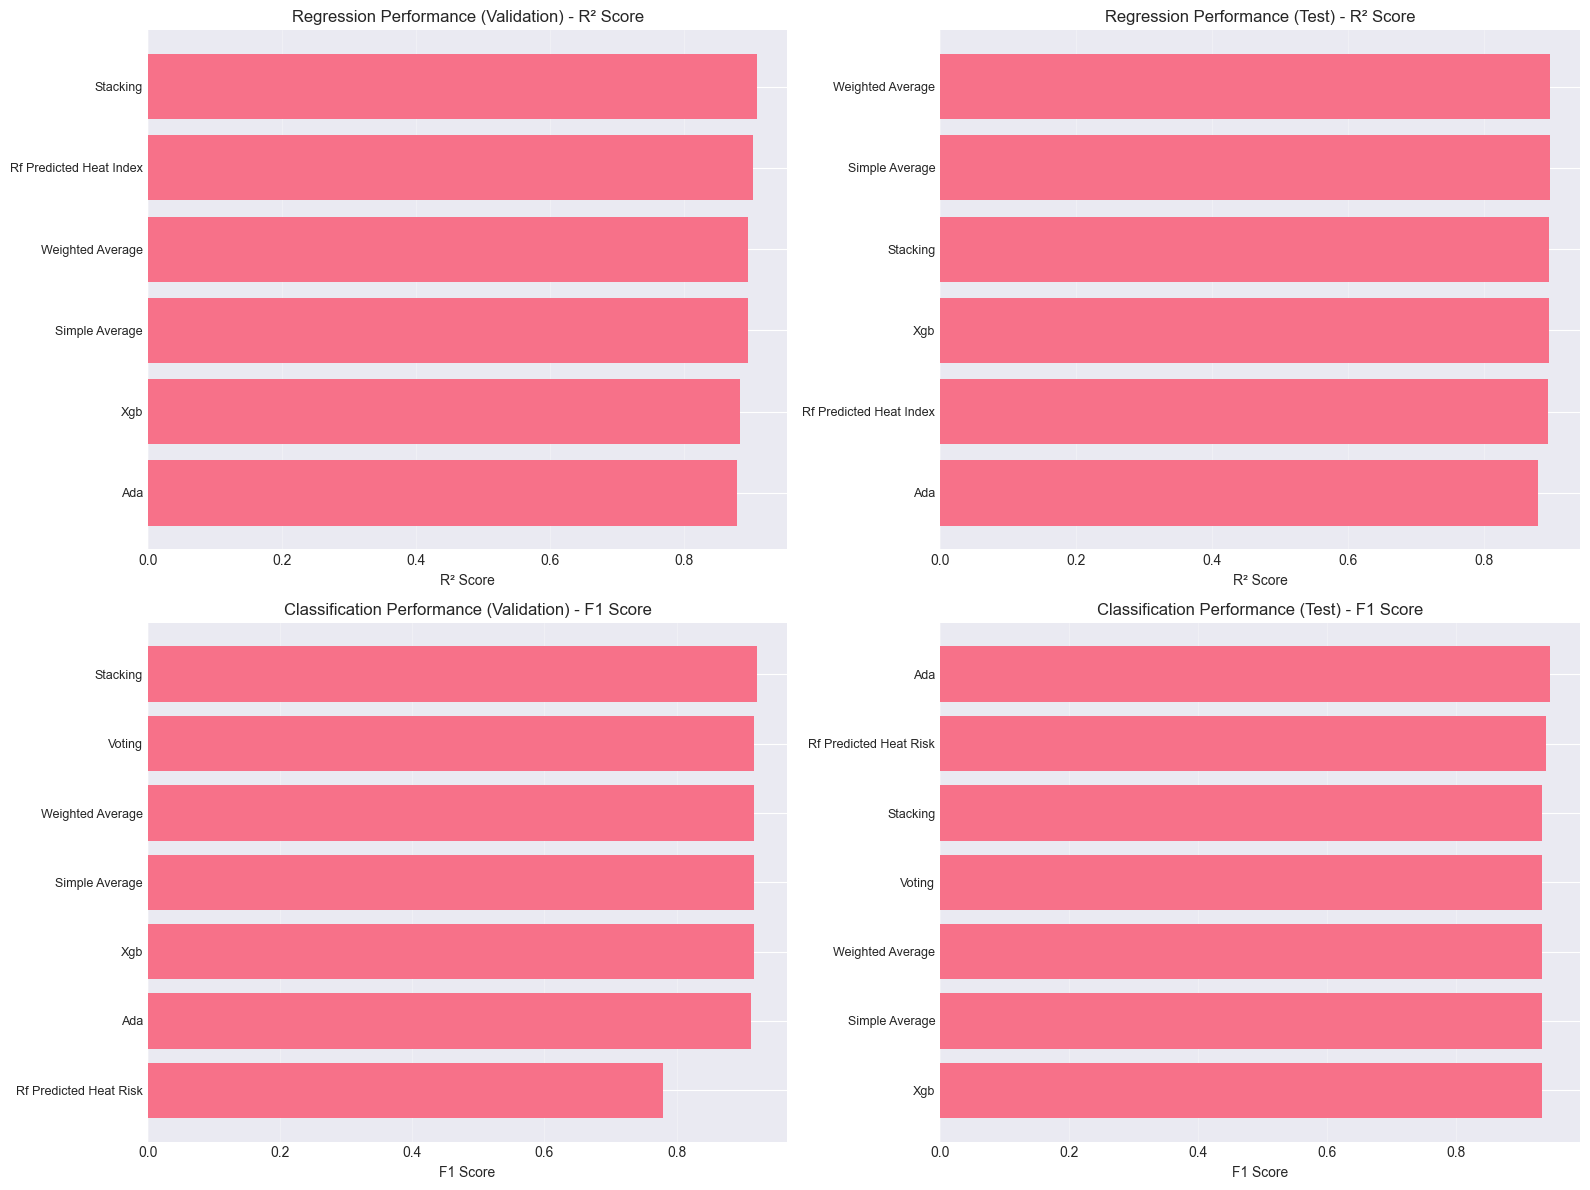

In [ ]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Regression - Validation
ax1 = axes[0, 0]
val_reg_plot = all_regression_results[all_regression_results['dataset'] == 'Validation'].copy()
val_reg_plot = val_reg_plot.sort_values('R²', ascending=True)
ax1.barh(val_reg_plot['model'], val_reg_plot['R²'])
ax1.set_xlabel('R² Score')
ax1.set_title('Regression Performance (Validation) - R² Score')
ax1.grid(axis='x', alpha=0.3)
# Adjust y-axis labels if model names are long
ax1.tick_params(axis='y', labelsize=9)

# Regression - Test
ax2 = axes[0, 1]
test_reg_plot = all_regression_results[all_regression_results['dataset'] == 'Test'].copy()
test_reg_plot = test_reg_plot.sort_values('R²', ascending=True)
ax2.barh(test_reg_plot['model'], test_reg_plot['R²'])
ax2.set_xlabel('R² Score')
ax2.set_title('Regression Performance (Test) - R² Score')
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='y', labelsize=9)

# Classification - Validation
ax3 = axes[1, 0]
val_cls_plot = all_classification_results[all_classification_results['dataset'] == 'Validation'].copy()
val_cls_plot = val_cls_plot.sort_values('F1', ascending=True)
ax3.barh(val_cls_plot['model'], val_cls_plot['F1'])
ax3.set_xlabel('F1 Score')
ax3.set_title('Classification Performance (Validation) - F1 Score')
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='y', labelsize=9)

# Classification - Test
ax4 = axes[1, 1]
test_cls_plot = all_classification_results[all_classification_results['dataset'] == 'Test'].copy()
test_cls_plot = test_cls_plot.sort_values('F1', ascending=True)
ax4.barh(test_cls_plot['model'], test_cls_plot['F1'])
ax4.set_xlabel('F1 Score')
ax4.set_title('Classification Performance (Test) - F1 Score')
ax4.grid(axis='x', alpha=0.3)
ax4.tick_params(axis='y', labelsize=9)

plt.tight_layout()
# Use models/ensemble directory
ensemble_dir = os.path.join(base_path, 'models', 'ensemble') if 'base_path' in globals() else os.path.join('models', 'ensemble')
os.makedirs(ensemble_dir, exist_ok=True)
plt.savefig(os.path.join(ensemble_dir, 'ensemble_comparison.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved comparison plot: {os.path.join(ensemble_dir, 'ensemble_comparison.png')}")
plt.show()


## Step 8: Save Ensemble Predictions and Models

Save all ensemble predictions and trained meta-learners.


In [ ]:
# Create ensemble directory in models/ensemble (use base_path if defined, otherwise current directory)
ensemble_dir = os.path.join(base_path, 'models', 'ensemble') if 'base_path' in globals() else os.path.join('models', 'ensemble')
os.makedirs(ensemble_dir, exist_ok=True)
print(f"✓ Created ensemble directory: {ensemble_dir}")

# Prepare prediction DataFrames with all ensemble methods
ensemble_val_predictions = pd.DataFrame({
    'Date': val_merged['Date'].values,
    'actual_heat_index': y_val_reg,
    'actual_heat_risk': y_val_cls,
    'simple_avg_predicted_heat_index': val_reg_simple if val_reg_simple is not None else np.nan,
    'weighted_avg_predicted_heat_index': val_reg_weighted if val_reg_weighted is not None else np.nan,
    'stacking_predicted_heat_index': val_reg_stacking if val_reg_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk': val_cls_simple_binary if val_cls_simple_binary is not None else np.nan,
    'weighted_avg_predicted_heat_risk': val_cls_weighted_binary if val_cls_weighted_binary is not None else np.nan,
    'voting_predicted_heat_risk': val_cls_voting_binary if val_cls_voting_binary is not None else np.nan,
    'stacking_predicted_heat_risk': val_cls_stacking if val_cls_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk_proba': val_cls_proba_simple if val_cls_proba_simple is not None else np.nan,
    'weighted_avg_predicted_heat_risk_proba': val_cls_proba_weighted if val_cls_proba_weighted is not None else np.nan,
    'stacking_predicted_heat_risk_proba': val_cls_stacking_proba if val_cls_stacking_proba is not None else np.nan
})

ensemble_test_predictions = pd.DataFrame({
    'Date': test_merged['Date'].values,
    'actual_heat_index': y_test_reg,
    'actual_heat_risk': y_test_cls,
    'simple_avg_predicted_heat_index': test_reg_simple if test_reg_simple is not None else np.nan,
    'weighted_avg_predicted_heat_index': test_reg_weighted if test_reg_weighted is not None else np.nan,
    'stacking_predicted_heat_index': test_reg_stacking if test_reg_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk': test_cls_simple_binary if test_cls_simple_binary is not None else np.nan,
    'weighted_avg_predicted_heat_risk': test_cls_weighted_binary if test_cls_weighted_binary is not None else np.nan,
    'voting_predicted_heat_risk': test_cls_voting_binary if test_cls_voting_binary is not None else np.nan,
    'stacking_predicted_heat_risk': test_cls_stacking if test_cls_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk_proba': test_cls_proba_simple if test_cls_proba_simple is not None else np.nan,
    'weighted_avg_predicted_heat_risk_proba': test_cls_proba_weighted if test_cls_proba_weighted is not None else np.nan,
    'stacking_predicted_heat_risk_proba': test_cls_stacking_proba if test_cls_stacking_proba is not None else np.nan
})

# Save predictions
ensemble_val_predictions.to_csv(os.path.join(ensemble_dir, 'predictions_val.csv'), index=False)
ensemble_test_predictions.to_csv(os.path.join(ensemble_dir, 'predictions_test.csv'), index=False)
print("✓ Saved ensemble predictions")

# Save meta-learners (stacking models)
if stacking_regressor is not None:
    joblib.dump(stacking_regressor, os.path.join(ensemble_dir, 'stacking_regressor.pkl'))
    print("✓ Saved stacking regressor")

if stacking_classifier is not None:
    joblib.dump(stacking_classifier, os.path.join(ensemble_dir, 'stacking_classifier.pkl'))
    print("✓ Saved stacking classifier")

# Save weights
weights_dict = {
    'regression_weights': reg_weights,
    'classification_weights': cls_weights,
    'classification_proba_weights': cls_proba_weights
}
import json
with open(os.path.join(ensemble_dir, 'ensemble_weights.json'), 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    weights_json = {}
    for key, val in weights_dict.items():
        if isinstance(val, dict):
            weights_json[key] = {k: float(v) for k, v in val.items()}
        else:
            weights_json[key] = val
    json.dump(weights_json, f, indent=2)
print("✓ Saved ensemble weights")

# Save performance results
all_regression_results.to_csv(os.path.join(ensemble_dir, 'regression_results.csv'), index=False)
all_classification_results.to_csv(os.path.join(ensemble_dir, 'classification_results.csv'), index=False)
print("✓ Saved performance results")

print("\n" + "=" * 80)
print("✓ All ensemble models and predictions saved successfully!")
print("=" * 80)


✓ Created ensemble directory: ..\ensemble
✓ Saved ensemble predictions
✓ Saved stacking regressor
✓ Saved stacking classifier
✓ Saved ensemble weights
✓ Saved performance results

✓ All ensemble models and predictions saved successfully!


## Summary

This notebook successfully created ensemble models combining predictions from:
- Random Forest
- XGBoost
- AdaBoost
- LSTM (Currently not available)

### Ensemble Methods Implemented:
1. **Simple Averaging**: Equal weights for all models
2. **Weighted Averaging**: Weights based on validation performance (R² for regression, F1 for classification)
3. **Voting**: Majority vote for classification
4. **Stacking**: Meta-learners (Ridge for regression, LogisticRegression for classification)

### Outputs Saved:
- `teams/ensemble/predictions_val.csv`: Validation set predictions
- `teams/ensemble/predictions_test.csv`: Test set predictions
- `teams/ensemble/stacking_regressor.pkl`: Trained stacking regressor
- `teams/ensemble/stacking_classifier.pkl`: Trained stacking classifier
- `teams/ensemble/ensemble_weights.json`: Weights used for weighted averaging
- `teams/ensemble/regression_results.csv`: Regression performance metrics
- `teams/ensemble/classification_results.csv`: Classification performance metrics
- `teams/ensemble/ensemble_comparison.png`: Visualization comparing all methods
